In [11]:
import pandas as pd
import json

# Load JSON with UTF-8 encoding
with open(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/feedback_structure.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)

# Load CSVs (also force UTF-8 if needed)
df1 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-1.csv', encoding='utf-8')
df2 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-2.csv', encoding='utf-8')
df3 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-3.csv', encoding='utf-8')

# Check relationships
if isinstance(json_data, dict):
    print("JSON keys:", list(json_data.keys()))
elif isinstance(json_data, list):
    print("JSON is a list/array with", len(json_data), "items")
else:
    print("JSON structure type:", type(json_data))

# Compare sizes
print(f"CSV1 rows: {len(df1)}, CSV2: {len(df2)}, CSV3: {len(df3)}")

# If JSON is a list, convert to DataFrame and compare columns
if isinstance(json_data, list) and len(json_data) > 0:
    json_df = pd.DataFrame(json_data)
    print("JSON columns:", json_df.columns.tolist())
    print("CSV1 columns:", df1.columns.tolist())


C:\Users\sneha\AppData\Local\Temp\ipykernel_8388\2001382737.py:9: DtypeWarning: Columns (6,10,16,43,44,45,46,47,48,49,51,52,53,54,57,58,62,65,66,67,68,71,72,76,77,78,80,82,87,88,90,91,92,93,94,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-1.csv', encoding='utf-8')


JSON keys: ['_id', 'feedbackTimeStamp', 'feedbackLanguage', 'pipelineInput', 'pipelineOutput', 'suggestedPipelineOutput', 'pipelineFeedback', 'taskFeedback', 'user_id', 'api_key_name']
CSV1 rows: 28379, CSV2: 1689, CSV3: 2725


In [15]:
if isinstance(json_data, dict):
    print("JSON keys:", list(json_data.keys()))
    # Convert dict to DataFrame if it contains tabular data
    try:
        json_df = pd.DataFrame(json_data)
    except ValueError:
        json_df = pd.DataFrame([json_data])  # wrap in list if single record
elif isinstance(json_data, list):
    print("JSON is a list/array with", len(json_data), "items")
    json_df = pd.DataFrame(json_data)
else:
    print("JSON structure type:", type(json_data))
    json_df = None

# Compare sizes
print(f"CSV1 rows: {len(df1)}, CSV2: {len(df2)}, CSV3: {len(df3)}")

# Compare columns if JSON was converted
if json_df is not None:
    print("\nJSON columns:", set(json_df.columns))
    print("CSV1 columns:", set(df1.columns))
    print("CSV2 columns:", set(df2.columns))
    print("CSV3 columns:", set(df3.columns))

    # Look for overlaps
    print("\nCommon with CSV1:", set(json_df.columns) & set(df1.columns))
    print("Common with CSV2:", set(json_df.columns) & set(df2.columns))
    print("Common with CSV3:", set(json_df.columns) & set(df3.columns))

JSON keys: ['_id', 'feedbackTimeStamp', 'feedbackLanguage', 'pipelineInput', 'pipelineOutput', 'suggestedPipelineOutput', 'pipelineFeedback', 'taskFeedback', 'user_id', 'api_key_name']
CSV1 rows: 28379, CSV2: 1689, CSV3: 2725

JSON columns: {'pipelineFeedback', 'feedbackTimeStamp', 'feedbackLanguage', '_id', 'taskFeedback', 'user_id', 'api_key_name', 'pipelineOutput', 'suggestedPipelineOutput', 'pipelineInput'}
CSV1 columns: {'pipelineOutput.pipelineResponse[2].audio[0].audioContent', 'taskFeedback[2].taskType', 'pipelineInput.pipelineTasks[2].config.gender', 'suggestedPipelineOutput.pipelineResponse[2].config.encoding', 'feedbackSource.application', 'pipelineInput.pipelineTasks[3].config.samplingRate', 'pipelineInput.pipelineTasks[1].config.language.sourceScriptCode', 'taskFeedback[6].taskType', 'suggestedPipelineOutput.pipelineResponse[0].audio[0].audioContent', 'pipelineFeedback.commonFeedback[0].feedbackType', 'pipelineInput.pipelineTasks[0].config.language.targetScriptCode', 'task

In [18]:
print("\n--- CSV Columns ---")
print("CSV1 columns:", df1.columns.tolist())
print("CSV2 columns:", df2.columns.tolist())
print("CSV3 columns:", df3.columns.tolist())
if json_df is not None:
    print("\n--- JSON Columns ---")
    print("JSON columns:", json_df.columns.tolist())


--- CSV Columns ---
CSV1 columns: ['_id', 'feedbackTimeStamp', 'feedbackLanguage', 'pipelineInput.pipelineTasks[0].taskType', 'pipelineInput.pipelineTasks[1].taskType', 'pipelineInput.pipelineTasks[2].taskType', 'pipelineInput.pipelineTasks[3].taskType', 'pipelineInput.pipelineTasks[0].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[1].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[2].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[3].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[0].config.language.targetLanguage', 'pipelineInput.pipelineTasks[1].config.language.targetLanguage', 'pipelineInput.pipelineTasks[0].config.serviceId', 'pipelineInput.pipelineTasks[1].config.serviceId', 'pipelineInput.pipelineTasks[2].config.serviceId', 'pipelineInput.pipelineTasks[3].config.serviceId', 'pipelineInput.inputData.input[0].source', 'pipelineOutput.pipelineResponse[0].taskType', 'pipelineOutput.pipelineResponse[1].taskType', 'pipelineOutp

In [19]:
# Show first 5 rows of each CSV
print("\n--- CSV1 Sample ---")
print(df1.head())




--- CSV1 Sample ---
                        _id  feedbackTimeStamp feedbackLanguage  \
0  64fc1c4c91e7414bb5307045         1689941259               en   
1  64fc1c4e91e7414bb5307046         1689941259               en   
2  6513d6c662f7012f9f3a01c1                691               en   
3  66c0a10c606db3dda019fc03         1723900171               en   
4  66d173ae75f6a2feea33b03d         1725002670               en   

  pipelineInput.pipelineTasks[0].taskType  \
0                             translation   
1                             translation   
2                             translation   
3                             translation   
4                             translation   

  pipelineInput.pipelineTasks[1].taskType  \
0                                     NaN   
1                                     NaN   
2                                     NaN   
3                                     NaN   
4                                     NaN   

  pipelineInput.pipelineTasks[2].t

In [20]:
print("\n--- CSV2 Sample ---")
print(df2.head())




--- CSV2 Sample ---
                        _id  feedbackTimeStamp feedbackLanguage  \
0  64fb0c060227afe757457247         1689941259               en   
1  64fb1aaf0227afe75745724b         1689941259               en   
2  64c391c303d6b06e7f17bbb8         1689941259               en   
3  64fc243a56c8777191364ee9         1689941259               en   
4  6513fdf8a78657829f621af5                480               en   

  pipelineInput.pipelineTasks[0].taskType  \
0                             translation   
1                             translation   
2                             translation   
3                             translation   
4                             translation   

  pipelineInput.pipelineTasks[1].taskType  \
0                                     NaN   
1                                     NaN   
2                                     NaN   
3                                     NaN   
4                                     NaN   

  pipelineInput.pipelineTasks[2].t

In [21]:
print("\n--- CSV3 Sample ---")
print(df3.head())


--- CSV3 Sample ---
                        _id  feedbackTimeStamp feedbackLanguage  \
0  64fc19d704007d4a4fa97f12         1689941259               en   
1  650e7f1e36d4503c2341e0ad                619               en   
2  64fc19d956c8777191364edf         1689941259               en   
3  64fc1b0056c8777191364ee0         1689941259               en   
4  6513ff75217adb03f8e73dfb                599               en   

  pipelineInput.pipelineTasks[0].taskType  \
0                             translation   
1                                     asr   
2                             translation   
3                             translation   
4                             translation   

  pipelineInput.pipelineTasks[1].taskType  \
0                                     NaN   
1                             translation   
2                                     NaN   
3                                     NaN   
4                                     NaN   

  pipelineInput.pipelineTasks[2].t

In [23]:
print(f"Rows -> CSV1: {len(df1)}, CSV2: {len(df2)}, CSV3: {len(df3)}")


Rows -> CSV1: 28379, CSV2: 1689, CSV3: 2725


In [24]:
print("CSV1 columns:", set(df1.columns))
print("CSV2 columns:", set(df2.columns))
print("CSV3 columns:", set(df3.columns))

print("\nCommon columns across all three:", set(df1.columns) & set(df2.columns) & set(df3.columns))


CSV1 columns: {'pipelineOutput.pipelineResponse[2].audio[0].audioContent', 'taskFeedback[2].taskType', 'pipelineInput.pipelineTasks[2].config.gender', 'suggestedPipelineOutput.pipelineResponse[2].config.encoding', 'feedbackSource.application', 'pipelineInput.pipelineTasks[3].config.samplingRate', 'pipelineInput.pipelineTasks[1].config.language.sourceScriptCode', 'taskFeedback[6].taskType', 'suggestedPipelineOutput.pipelineResponse[0].audio[0].audioContent', 'pipelineFeedback.commonFeedback[0].feedbackType', 'pipelineInput.pipelineTasks[0].config.language.targetScriptCode', 'taskFeedback[4].taskType', 'pipelineOutput.pipelineResponse[0].config.encoding', 'suggestedPipelineOutput.pipelineResponse[0].taskType', 'pipelineFeedback.commonFeedback[2].feedbackType', 'pipelineOutput.pipelineResponse[0].output[0].audio.audioUri', 'taskFeedback[3].commonFeedback[0].feedbackType', 'suggestedPipelineOutput.pipelineResponse[2].config.language.sourceScriptCode', 'suggestedPipelineOutput.pipelineRespo

In [25]:
# Total number of columns in each CSV
print(f"CSV1 total columns: {len(df1.columns)}")
print(f"CSV2 total columns: {len(df2.columns)}")
print(f"CSV3 total columns: {len(df3.columns)}")

# Show all column names
print("\n--- CSV Columns ---")
print("CSV1 columns:", df1.columns.tolist())
print("CSV2 columns:", df2.columns.tolist())
print("CSV3 columns:", df3.columns.tolist())

# Compare similarities
common_cols = set(df1.columns) & set(df2.columns) & set(df3.columns)
unique_csv1 = set(df1.columns) - (set(df2.columns) | set(df3.columns))
unique_csv2 = set(df2.columns) - (set(df1.columns) | set(df3.columns))
unique_csv3 = set(df3.columns) - (set(df1.columns) | set(df2.columns))

print("\n--- Column Similarity ---")
print("Common columns across all three:", common_cols)
print("Unique to CSV1:", unique_csv1)
print("Unique to CSV2:", unique_csv2)
print("Unique to CSV3:", unique_csv3)


CSV1 total columns: 129
CSV2 total columns: 145
CSV3 total columns: 94

--- CSV Columns ---
CSV1 columns: ['_id', 'feedbackTimeStamp', 'feedbackLanguage', 'pipelineInput.pipelineTasks[0].taskType', 'pipelineInput.pipelineTasks[1].taskType', 'pipelineInput.pipelineTasks[2].taskType', 'pipelineInput.pipelineTasks[3].taskType', 'pipelineInput.pipelineTasks[0].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[1].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[2].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[3].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[0].config.language.targetLanguage', 'pipelineInput.pipelineTasks[1].config.language.targetLanguage', 'pipelineInput.pipelineTasks[0].config.serviceId', 'pipelineInput.pipelineTasks[1].config.serviceId', 'pipelineInput.pipelineTasks[2].config.serviceId', 'pipelineInput.pipelineTasks[3].config.serviceId', 'pipelineInput.inputData.input[0].source', 'pipelineOutput.pipelineResponse[0].

In [27]:
# Total number of columns
print(f"CSV1 total columns: {len(df1.columns)}")
print(f"CSV2 total columns: {len(df2.columns)}")
print(f"CSV3 total columns: {len(df3.columns)}")

# Show all column names
print("\n--- CSV Columns ---")
print("CSV1 columns:", df1.columns.tolist())
print("CSV2 columns:", df2.columns.tolist())
print("CSV3 columns:", df3.columns.tolist())

# Common and unique columns
common_cols = set(df1.columns) & set(df2.columns) & set(df3.columns)
print("\nCommon columns across all three:", common_cols)

# Pairwise overlaps
print("CSV1 ∩ CSV2:", set(df1.columns) & set(df2.columns))
print("CSV1 ∩ CSV3:", set(df1.columns) & set(df3.columns))
print("CSV2 ∩ CSV3:", set(df2.columns) & set(df3.columns))

# ✅ Numeric-only similarity check
numeric_common = [col for col in common_cols 
                  if pd.api.types.is_numeric_dtype(df1[col]) 
                  and pd.api.types.is_numeric_dtype(df2[col]) 
                  and pd.api.types.is_numeric_dtype(df3[col])]

if numeric_common:
    print("\nNumeric common columns:", numeric_common)
    print("\nCorrelation CSV1 vs CSV2:")
    print(df1[numeric_common].corrwith(df2[numeric_common], axis=0))
    print("\nCorrelation CSV1 vs CSV3:")
    print(df1[numeric_common].corrwith(df3[numeric_common], axis=0))
    print("\nCorrelation CSV2 vs CSV3:")
    print(df2[numeric_common].corrwith(df3[numeric_common], axis=0))
else:
    print("\nNo numeric columns in common across all three CSVs.")


CSV1 total columns: 129
CSV2 total columns: 145
CSV3 total columns: 94

--- CSV Columns ---
CSV1 columns: ['_id', 'feedbackTimeStamp', 'feedbackLanguage', 'pipelineInput.pipelineTasks[0].taskType', 'pipelineInput.pipelineTasks[1].taskType', 'pipelineInput.pipelineTasks[2].taskType', 'pipelineInput.pipelineTasks[3].taskType', 'pipelineInput.pipelineTasks[0].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[1].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[2].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[3].config.language.sourceLanguage', 'pipelineInput.pipelineTasks[0].config.language.targetLanguage', 'pipelineInput.pipelineTasks[1].config.language.targetLanguage', 'pipelineInput.pipelineTasks[0].config.serviceId', 'pipelineInput.pipelineTasks[1].config.serviceId', 'pipelineInput.pipelineTasks[2].config.serviceId', 'pipelineInput.pipelineTasks[3].config.serviceId', 'pipelineInput.inputData.input[0].source', 'pipelineOutput.pipelineResponse[0].

CSV1 total columns: 129
CSV2 total columns: 145
CSV3 total columns: 94

Common across all three: 91
CSV1 ∩ CSV2: 93
CSV1 ∩ CSV3: 92
CSV2 ∩ CSV3: 91

--- Column Overlap Matrix ---
      CSV1  CSV2  CSV3
CSV1   129    93    92
CSV2    93   145    91
CSV3    92    91    94


C:\Users\sneha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib_venn\layout\venn3\pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


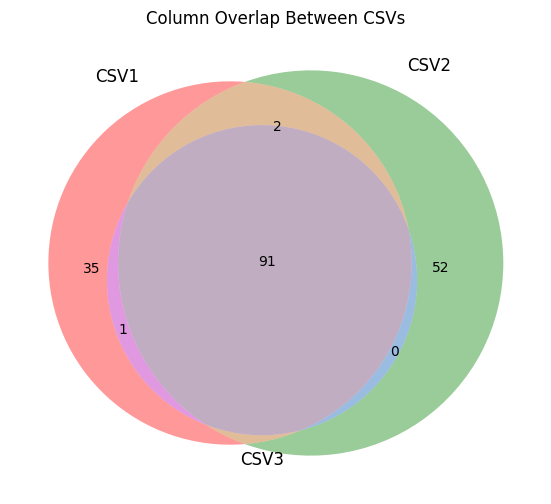

In [32]:
import pandas as pd
try:
    from matplotlib_venn import venn3
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib-venn"])
    from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Define sets of columns
cols1, cols2, cols3 = set(df1.columns), set(df2.columns), set(df3.columns)

# Total number of columns
print("CSV1 total columns:", len(cols1))
print("CSV2 total columns:", len(cols2))
print("CSV3 total columns:", len(cols3))

# Common overlaps
print("\nCommon across all three:", len(cols1 & cols2 & cols3))
print("CSV1 ∩ CSV2:", len(cols1 & cols2))
print("CSV1 ∩ CSV3:", len(cols1 & cols3))
print("CSV2 ∩ CSV3:", len(cols2 & cols3))

# --- Matrix of overlaps ---
matrix = pd.DataFrame({
    "CSV1": [len(cols1), len(cols1 & cols2), len(cols1 & cols3)],
    "CSV2": [len(cols1 & cols2), len(cols2), len(cols2 & cols3)],
    "CSV3": [len(cols1 & cols3), len(cols2 & cols3), len(cols3)]
}, index=["CSV1", "CSV2", "CSV3"])

print("\n--- Column Overlap Matrix ---")
print(matrix)

# --- Venn Diagram ---
plt.figure(figsize=(8,6))
venn3([cols1, cols2, cols3], set_labels=('CSV1', 'CSV2', 'CSV3'))
plt.title("Column Overlap Between CSVs")
plt.show()


=== Row Overlap Analysis ===
CSV1 total rows: 28,379
CSV2 total rows: 1,689
CSV3 total rows: 2,725

--- Common Rows ---
Rows in all 3 CSVs: 0
Rows in CSV1 & CSV2 only: 0
Rows in CSV1 & CSV3 only: 0
Rows in CSV2 & CSV3 only: 0

--- Unique Rows ---
Only in CSV1: 28,379
Only in CSV2: 1,689
Only in CSV3: 2,725


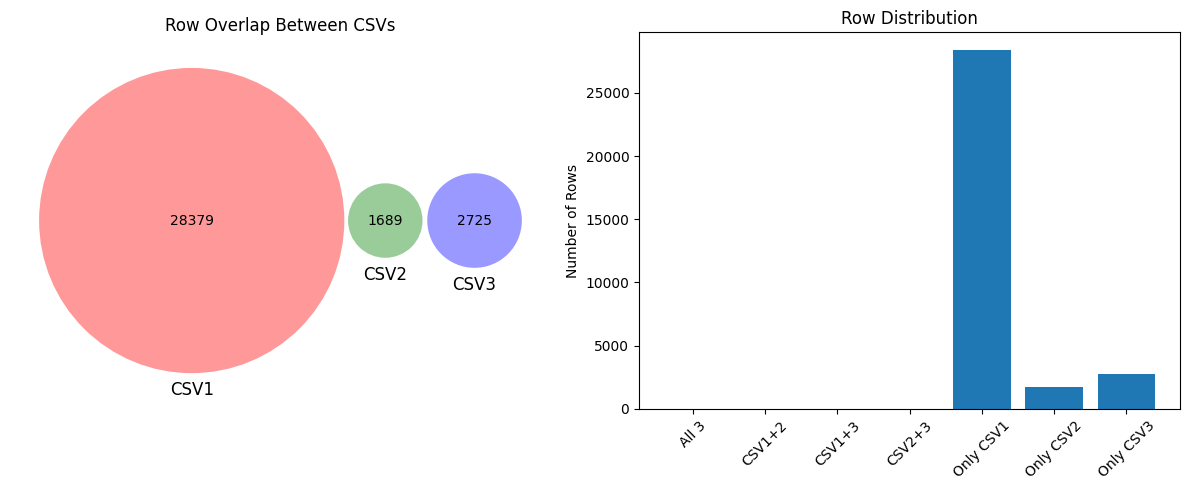

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Load only the ID column (_id) from each CSV
ids_csv1 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-1.csv', usecols=['_id'])
ids_csv2 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-2.csv', usecols=['_id'])
ids_csv3 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-3.csv', usecols=['_id'])

# Convert to sets
set1, set2, set3 = set(ids_csv1['_id']), set(ids_csv2['_id']), set(ids_csv3['_id'])

print("=== Row Overlap Analysis ===")
print(f"CSV1 total rows: {len(set1):,}")
print(f"CSV2 total rows: {len(set2):,}")
print(f"CSV3 total rows: {len(set3):,}")

# Overlaps
common_all = set1 & set2 & set3
common_12 = set1 & set2
common_13 = set1 & set3
common_23 = set2 & set3

print("\n--- Common Rows ---")
print(f"Rows in all 3 CSVs: {len(common_all):,}")
print(f"Rows in CSV1 & CSV2 only: {len(common_12 - common_all):,}")
print(f"Rows in CSV1 & CSV3 only: {len(common_13 - common_all):,}")
print(f"Rows in CSV2 & CSV3 only: {len(common_23 - common_all):,}")

# Unique rows
unique_1 = set1 - set2 - set3
unique_2 = set2 - set1 - set3
unique_3 = set3 - set1 - set2

print("\n--- Unique Rows ---")
print(f"Only in CSV1: {len(unique_1):,}")
print(f"Only in CSV2: {len(unique_2):,}")
print(f"Only in CSV3: {len(unique_3):,}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Venn diagram
venn3([set1, set2, set3], set_labels=('CSV1', 'CSV2', 'CSV3'), ax=axes[0])
axes[0].set_title("Row Overlap Between CSVs")

# Bar chart
categories = ['All 3', 'CSV1+2', 'CSV1+3', 'CSV2+3', 'Only CSV1', 'Only CSV2', 'Only CSV3']
counts = [len(common_all), len(common_12 - common_all), len(common_13 - common_all),
          len(common_23 - common_all), len(unique_1), len(unique_2), len(unique_3)]

axes[1].bar(categories, counts)
axes[1].set_title("Row Distribution")
axes[1].set_ylabel("Number of Rows")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [35]:
import json
import pandas as pd

# Load JSON
with open('feedback_structure.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)

# See first record structure
print("=== First JSON Record Structure ===")
first_record = json_data[0] if isinstance(json_data, list) else json_data

def print_structure(obj, indent=0):
    """Print nested structure of JSON"""
    if isinstance(obj, dict):
        for key, value in list(obj.items())[:5]:  # First 5 items only
            print("  " * indent + f"📁 {key}")
            print_structure(value, indent + 1)
    elif isinstance(obj, list):
        print("  " * indent + f"📋 List with {len(obj)} items")
        if obj:
            print_structure(obj[0], indent + 1)
    else:
        print("  " * indent + f"📄 Value: {str(obj)[:50]}...")

print_structure(first_record)

# Convert JSON to DataFrame if it's a list of records
if isinstance(json_data, list):
    json_df = pd.DataFrame(json_data)
    # Show actual data sample
    print("\n=== Sample Data from JSON ===")
    sample = json_df.head(1).to_dict('records')[0]
    for key, value in sample.items():
        if isinstance(value, (dict, list)):
            print(f"\n{key}:")
            print(f"  Type: {type(value).__name__}")
            print(f"  Content: {str(value)[:100]}...")
        else:
            print(f"\n{key}: {value}")
else:
    print("\nJSON is not a list of records, cannot convert to DataFrame directly.")


=== First JSON Record Structure ===
📁 _id
  📁 $oid
    📄 Value: 646f2eb0e8b7aacb8f161c33...
📁 feedbackTimeStamp
  📄 Value: 1684737381...
📁 feedbackLanguage
  📄 Value: en...
📁 pipelineInput
  📁 pipelineTasks
    📋 List with 1 items
      📁 taskType
        📄 Value: translation...
      📁 config
        📁 serviceId
          📄 Value: ai4bharat/indictrans-fairseq-i2e-gpu--t4...
        📁 language
          📁 sourceLanguage
            📄 Value: hi...
          📁 sourceScriptCode
            📄 Value: ...
  📁 inputData
    📋 List with 1 items
      📁 input
        📋 List with 1 items
          📁 source
            📄 Value: टेस्ट...
  📁 controlConfig
    📁 dataTracking
      📄 Value: True...
📁 pipelineOutput
  📁 controlConfig
    📁 dataTracking
      📄 Value: True...
  📁 pipelineResponse
    📋 List with 1 items
      📁 taskType
        📄 Value: translation...
      📁 output
        📋 List with 1 items
          📁 source
            📄 Value: टेस्ट...
          📁 target
            📄 Value: tes

In [ ]:
import json
import pandas as pd

with open(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/feedback_structure.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)

if isinstance(json_data, list):
    json_df = pd.DataFrame(json_data)
else:
    json_df = pd.DataFrame([json_data])

print("=== JSON Stats ===")
print(f"Rows in JSON: {len(json_df)}")
print(f"Columns in JSON: {len(json_df.columns)}")
print("JSON columns:", json_df.columns.tolist())

df1 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-1.csv', encoding='utf-8')
df2 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-2.csv', encoding='utf-8')
df3 = pd.read_csv(r'C:/Users/sneha/Downloads/BHASHHINI/FEEDBACK_PROJECT/Data/feedback/dhruva.feedback-3.csv', encoding='utf-8')

print("\n=== CSV Stats ===")
print(f"CSV1 rows: {len(df1)}, columns: {len(df1.columns)}")
print(f"CSV2 rows: {len(df2)}, columns: {len(df2.columns)}")
print(f"CSV3 rows: {len(df3)}, columns: {len(df3.columns)}")


SyntaxError: unterminated f-string literal (detected at line 28) (247266809.py, line 28)